In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

#CARREGAMENTO DOS DADOS
df = pd.read_csv("datakaggle.csv")

print("--- ESTATÍSTICAS DESCRITIVAS GERAIS ---")
#Exibe a análise descritiva das variáveis numéricas (como os scores de governança, ambiental, social)
print(df.describe().T)
print("\n" + "-"*50 + "\n")
print("Análise de valores ausentes:")
df.isnull().sum().sort_values(ascending=False)


--- ESTATÍSTICAS DESCRITIVAS GERAIS ---
                   count           mean            std     min        25%  \
environment_score  722.0     404.806094     145.103870   200.0     240.00   
social_score       722.0     292.182825      57.017406   160.0     243.00   
governance_score   722.0     278.761773      47.031536    75.0     235.00   
total_score        722.0     975.750693     218.751796   600.0     763.00   
cik                722.0  989792.497230  581681.496480  1800.0  723157.25   

                         50%         75%        max  
environment_score      483.0      518.75      719.0  
social_score           302.0      322.75      667.0  
governance_score       300.0      310.00      475.0  
total_score           1046.0     1144.00     1536.0  
cik                1046189.0  1470094.25  1914023.0  

--------------------------------------------------

Análise de valores ausentes:


logo                    20
weburl                  16
industry                13
ticker                   0
name                     0
exchange                 0
currency                 0
environment_grade        0
environment_level        0
social_grade             0
social_level             0
governance_grade         0
governance_level         0
environment_score        0
social_score             0
governance_score         0
total_score              0
last_processing_date     0
total_grade              0
total_level              0
cik                      0
dtype: int64

In [52]:
# Quantificar outliers
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)

IQR = Q3 - Q1

outliers = df[
    (df[col] < Q1 - 1.5*IQR) |
    (df[col] > Q3 + 1.5*IQR)
]

print(len(outliers))

0


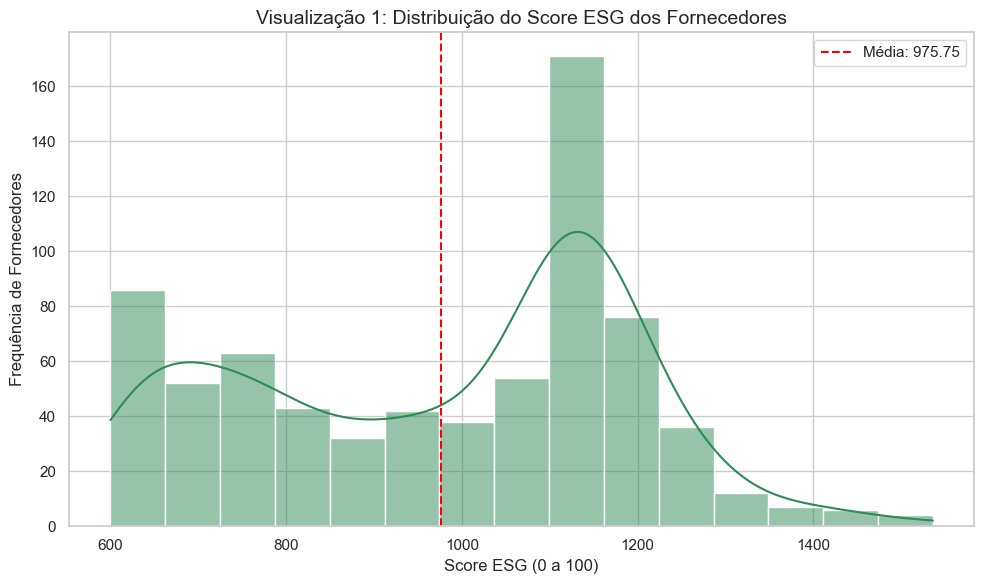


O histograma permite identificar a concentração dos fornecedores em determinadas faixas de score ESG.
A posição da média (linha vermelha) mostra o desempenho geral da base analisada.
Uma distribuição concentrada em scores elevados sugere maturidade ESG da cadeia de fornecedores.
Caso existam caudas ou assimetrias, elas indicam grupos específicos com desempenho muito superior ou inferior à média.
A densidade (KDE) auxilia na identificação de possíveis agrupamentos naturais de fornecedores.

A distribuição do score ESG permite avaliar como o desempenho está espalhado entre os fornecedores. 
A concentração dos valores em determinadas faixas auxilia na identificação do perfil predominante da base, 
enquanto a média serve como referência para comparações e futuras segmentações.A distribuição do score
ESG permite avaliar como o desempenho está espalhado entre os fornecedores. 
A concentração dos valores em determinadas faixas auxilia na identificação do perfil predominante da base,
enquanto

In [53]:
# 1. VISUALIZAÇÃO 1: DISTRIBUIÇÃO DA VARIÁVEL ALVO (SCORE ESG)
plt.figure()
sns.histplot(data=df, x='total_score', kde=True, color='seagreen', bins=15)
plt.title('Visualização 1: Distribuição do Score ESG dos Fornecedores', fontsize=14)
plt.xlabel('Score ESG (0 a 100)')
plt.ylabel('Frequência de Fornecedores')
plt.axvline(df['total_score'].mean(), color='red', linestyle='--', label=f"Média: {df['total_score'].mean():.2f}")
plt.legend()
plt.tight_layout()
plt.show()

#insights
print("""
O histograma permite identificar a concentração dos fornecedores em determinadas faixas de score ESG.
A posição da média (linha vermelha) mostra o desempenho geral da base analisada.
Uma distribuição concentrada em scores elevados sugere maturidade ESG da cadeia de fornecedores.
Caso existam caudas ou assimetrias, elas indicam grupos específicos com desempenho muito superior ou inferior à média.
A densidade (KDE) auxilia na identificação de possíveis agrupamentos naturais de fornecedores.
      
A distribuição do score ESG permite avaliar como o desempenho está espalhado entre os fornecedores. 
A concentração dos valores em determinadas faixas auxilia na identificação do perfil predominante da base, 
enquanto a média serve como referência para comparações e futuras segmentações.A distribuição do score
ESG permite avaliar como o desempenho está espalhado entre os fornecedores. 
A concentração dos valores em determinadas faixas auxilia na identificação do perfil predominante da base,
enquanto a média serve como referência para comparações e futuras segmentações.
""")
print("\n" + "-"*50 + "\n")

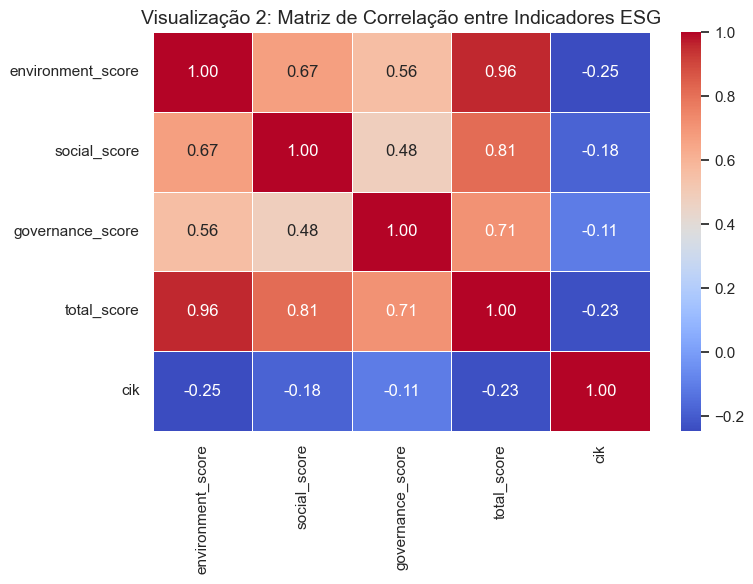


Identifica quais pilares ESG apresentam maior associação entre si.
Permite verificar quais variáveis mais influenciam o score ESG total.
Correlações fortes indicam que melhorias em um pilar tendem a estar associadas a melhorias em outro.
Correlações fracas sugerem independência entre dimensões ESG.
Auxilia na seleção de variáveis para modelos preditivos.

A matriz de correlação evidencia o grau de associação linear entre os pilares ESG e o score total. 
Correlações elevadas sugerem que empresas com bom desempenho em uma dimensão tendem a apresentar resultados 
superiores nas demais, enquanto correlações reduzidas indicam comportamentos mais independentes.


--------------------------------------------------



In [54]:
# 2. VISUALIZAÇÃO 2: MATRIZ DE CORRELAÇÃO
plt.figure(figsize=(8, 6))
# Filtrando apenas colunas numéricas relevantes para o cálculo ESG (ex: E_Score, S_Score, G_Score)
colunas_esg = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]
corr_matrix = df[colunas_esg].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Visualização 2: Matriz de Correlação entre Indicadores ESG', fontsize=14)
plt.tight_layout()
plt.show()

#insights
print("""
Identifica quais pilares ESG apresentam maior associação entre si.
Permite verificar quais variáveis mais influenciam o score ESG total.
Correlações fortes indicam que melhorias em um pilar tendem a estar associadas a melhorias em outro.
Correlações fracas sugerem independência entre dimensões ESG.
Auxilia na seleção de variáveis para modelos preditivos.

A matriz de correlação evidencia o grau de associação linear entre os pilares ESG e o score total. 
Correlações elevadas sugerem que empresas com bom desempenho em uma dimensão tendem a apresentar resultados 
superiores nas demais, enquanto correlações reduzidas indicam comportamentos mais independentes.
""")
print("\n" + "-"*50 + "\n")

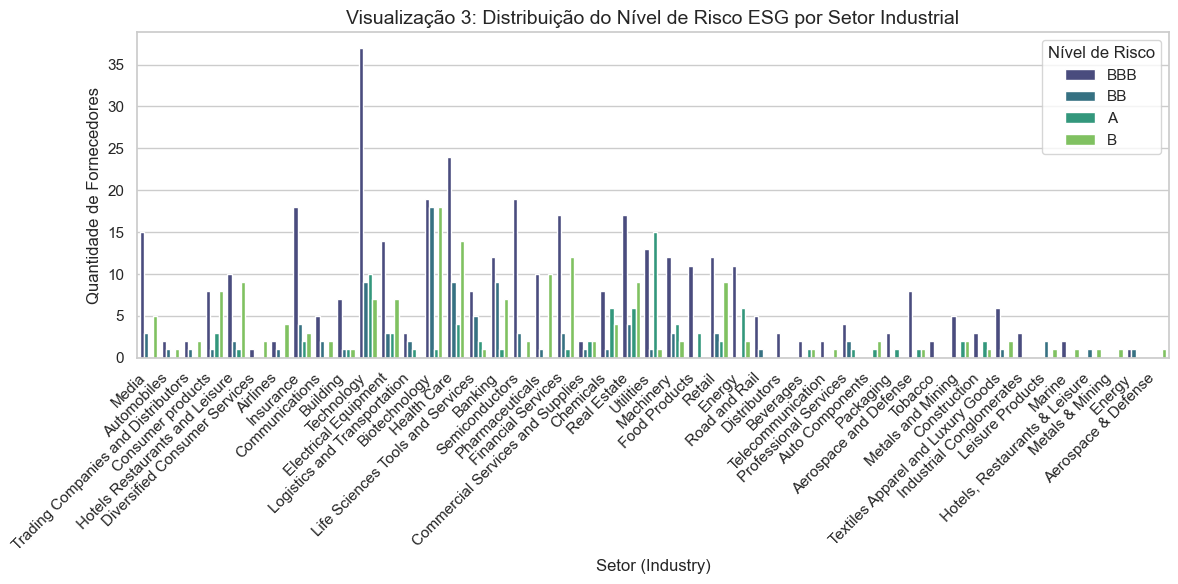


Permite identificar setores com maior concentração de empresas em cada faixa ESG.
Revela diferenças de maturidade ESG entre segmentos econômicos.
Ajuda a localizar setores que podem demandar maior atenção em políticas de sustentabilidade.
Evidencia possíveis padrões setoriais de desempenho ESG.

A distribuição das classificações ESG por setor permite comparar o perfil de desempenho entre diferentes 
segmentos econômicos. Setores com maior presença de classificações elevadas tendem a demonstrar maior 
maturidade em práticas ESG, enquanto setores com predominância de classificações inferiores podem representar 
oportunidades de melhoria.



In [55]:
# 3. VISUALIZAÇÃO 3: ANÁLISE DE CLASSES POR SETOR (INDUSTRY)
plt.figure(figsize=(12, 6))
# Cruzando o nível de risco gerado com o setor industrial do fornecedor
sns.countplot(data=df, x='industry', hue='total_grade', palette='viridis')
plt.title('Visualização 3: Distribuição do Nível de Risco ESG por Setor Industrial', fontsize=14)
plt.xlabel('Setor (Industry)')
plt.ylabel('Quantidade de Fornecedores')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Nível de Risco')
plt.tight_layout()
plt.show()

#insights
print("""
Permite identificar setores com maior concentração de empresas em cada faixa ESG.
Revela diferenças de maturidade ESG entre segmentos econômicos.
Ajuda a localizar setores que podem demandar maior atenção em políticas de sustentabilidade.
Evidencia possíveis padrões setoriais de desempenho ESG.
      
A distribuição das classificações ESG por setor permite comparar o perfil de desempenho entre diferentes 
segmentos econômicos. Setores com maior presença de classificações elevadas tendem a demonstrar maior 
maturidade em práticas ESG, enquanto setores com predominância de classificações inferiores podem representar 
oportunidades de melhoria.
""")


Environmental Score
Avalia a distribuição dos indicadores ambientais.
Identifica possíveis outliers ambientais.
Permite verificar assimetria e dispersão.

Social Score
Mostra a concentração dos indicadores sociais.
Permite detectar empresas muito acima ou abaixo da média.

Governance Score
Evidencia a consistência dos indicadores de governança.
Facilita a identificação de comportamentos extremos.

Total Score
Resume o comportamento geral do desempenho ESG.
Permite avaliar a variabilidade da base analisada.

boxplots
Outliers representam empresas com desempenho muito diferente da maioria.
Caixas maiores indicam maior dispersão.
Caixas menores indicam maior homogeneidade.



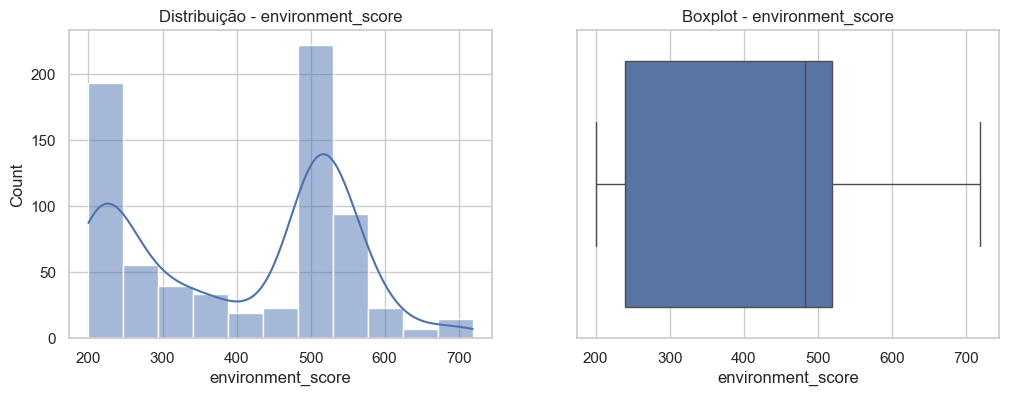

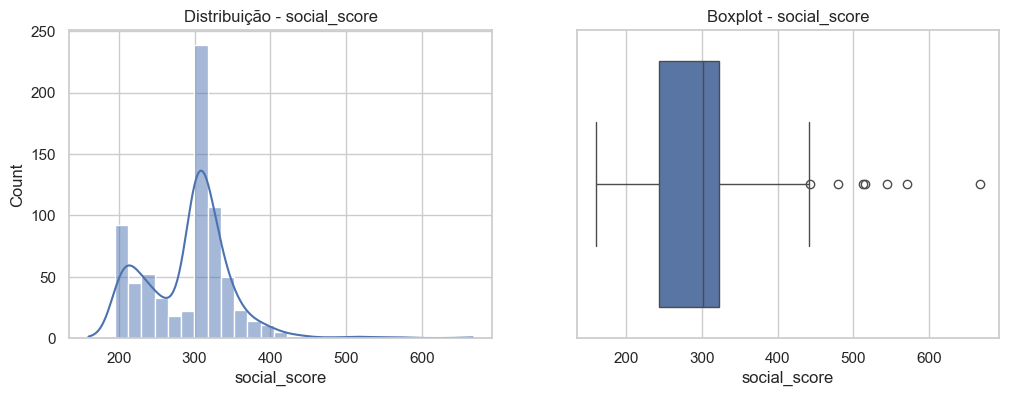

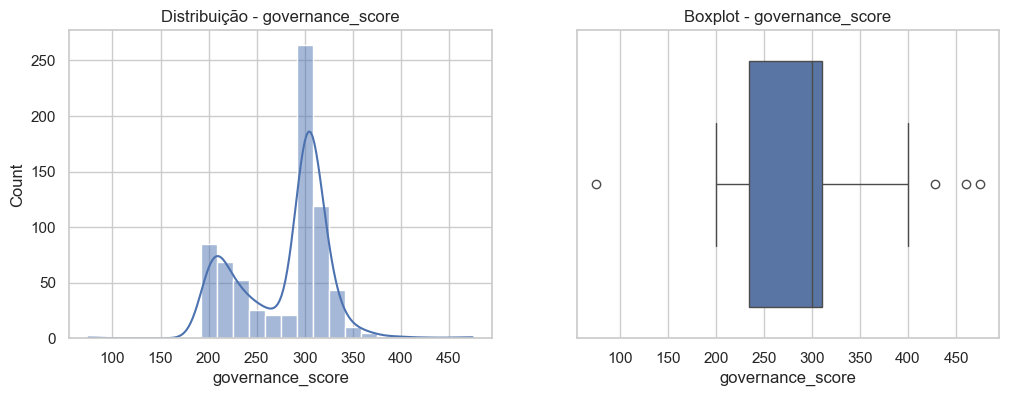

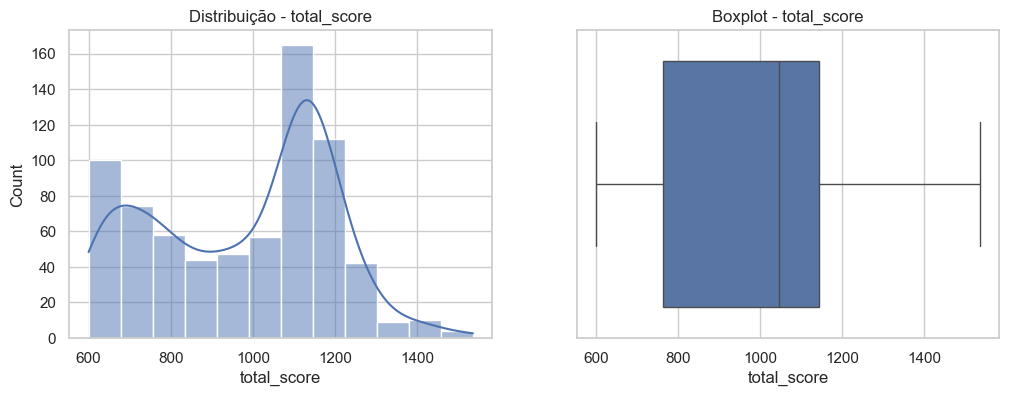

In [56]:
# 4. Análise Univariada Avançada
for col in ['environment_score','social_score',
            'governance_score','total_score']:

    fig, ax = plt.subplots(1,2, figsize=(12,4))

    sns.histplot(df[col], kde=True, ax=ax[0])
    ax[0].set_title(f'Distribuição - {col}')

    sns.boxplot(x=df[col], ax=ax[1])
    ax[1].set_title(f'Boxplot - {col}')

#insights
print("""
Environmental Score
Avalia a distribuição dos indicadores ambientais.
Identifica possíveis outliers ambientais.
Permite verificar assimetria e dispersão.

Social Score
Mostra a concentração dos indicadores sociais.
Permite detectar empresas muito acima ou abaixo da média.

Governance Score
Evidencia a consistência dos indicadores de governança.
Facilita a identificação de comportamentos extremos.

Total Score
Resume o comportamento geral do desempenho ESG.
Permite avaliar a variabilidade da base analisada.

boxplots
Outliers representam empresas com desempenho muito diferente da maioria.
Caixas maiores indicam maior dispersão.
Caixas menores indicam maior homogeneidade.
""")


Empresas com bom desempenho ambiental tendem ou não a apresentar bom desempenho social.
Permite identificar qual dimensão possui maior influência sobre o score total.
Correlações elevadas reforçam a consistência entre práticas ESG.

A análise evidencia como os pilares ESG se relacionam entre si. 
A força dessas correlações auxilia na compreensão da estrutura dos dados e na identificação dos fatores 
mais associados ao desempenho ESG global.



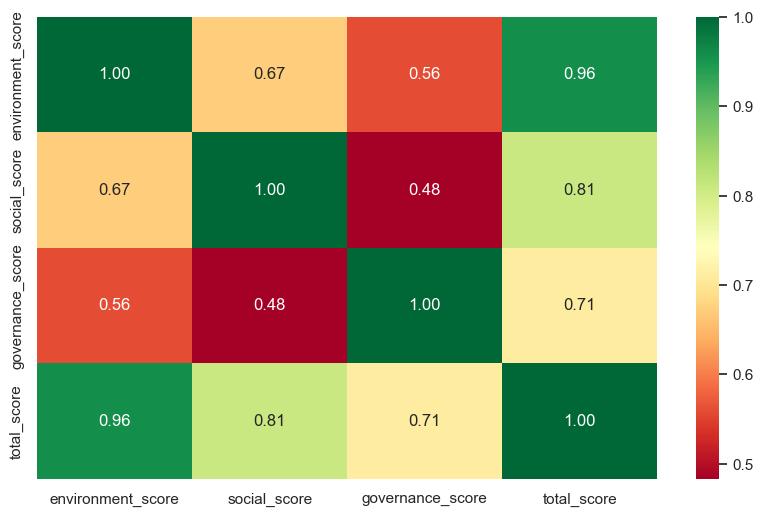

In [57]:
# 5. Correlação entre os pilares ESG
corr = df[
[
'environment_score',
'social_score',
'governance_score',
'total_score'
]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='RdYlGn',
    fmt='.2f'
)

#insights
print("""
Empresas com bom desempenho ambiental tendem ou não a apresentar bom desempenho social.
Permite identificar qual dimensão possui maior influência sobre o score total.
Correlações elevadas reforçam a consistência entre práticas ESG.

A análise evidencia como os pilares ESG se relacionam entre si. 
A força dessas correlações auxilia na compreensão da estrutura dos dados e na identificação dos fatores 
mais associados ao desempenho ESG global.
""")  


Permite comparar a distribuição dos scores ESG entre setores.
Setores com caixas menores apresentam comportamento mais homogêneo.
Setores com caixas maiores apresentam maior heterogeneidade.
Outliers representam empresas com desempenho excepcional dentro do setor.

A comparação dos scores ESG entre setores permite avaliar diferenças estruturais de desempenho e 
identificar segmentos mais consistentes ou mais dispersos em relação às práticas ESG.



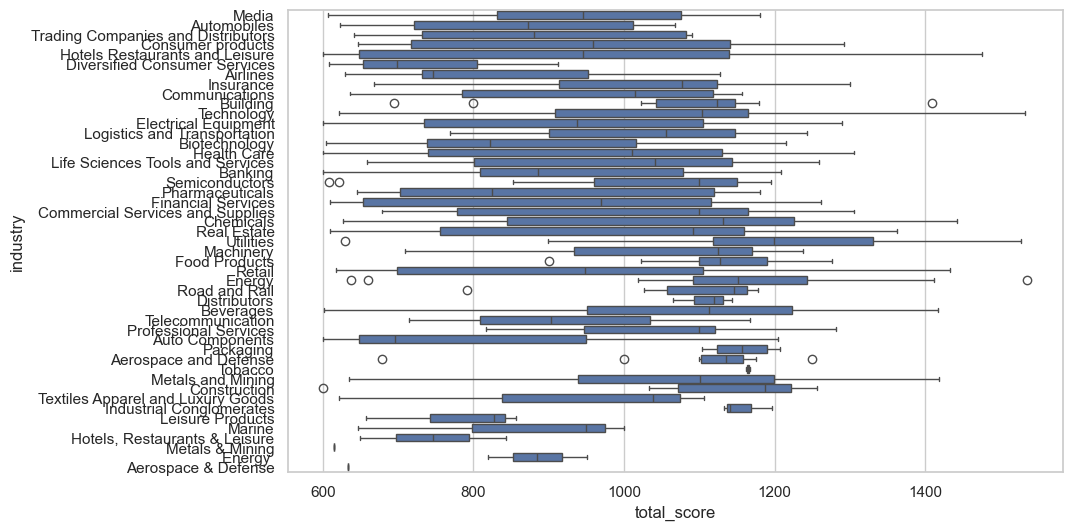

In [58]:
# 6. Análise por Setor (Industry)

# Média ESG por setor
industry_score = (
    df.groupby('industry')['total_score']
      .mean()
      .sort_values(ascending=False)
)

sns.boxplot(
    data=df,
    x='total_score',
    y='industry'
)

#insights
print("""
Permite comparar a distribuição dos scores ESG entre setores.
Setores com caixas menores apresentam comportamento mais homogêneo.
Setores com caixas maiores apresentam maior heterogeneidade.
Outliers representam empresas com desempenho excepcional dentro do setor.
      
A comparação dos scores ESG entre setores permite avaliar diferenças estruturais de desempenho e 
identificar segmentos mais consistentes ou mais dispersos em relação às práticas ESG.
""")

In [59]:
industry_score.head(10)

industry
Utilities                   1190.633333
Tobacco                     1165.000000
Industrial Conglomerates    1157.000000
Packaging                   1156.000000
Energy                      1142.263158
Food Products               1131.071429
Distributors                1109.666667
Aerospace and Defense       1089.700000
Construction                1082.666667
Road and Rail               1076.333333
Name: total_score, dtype: float64

<Axes: ylabel='industry'>

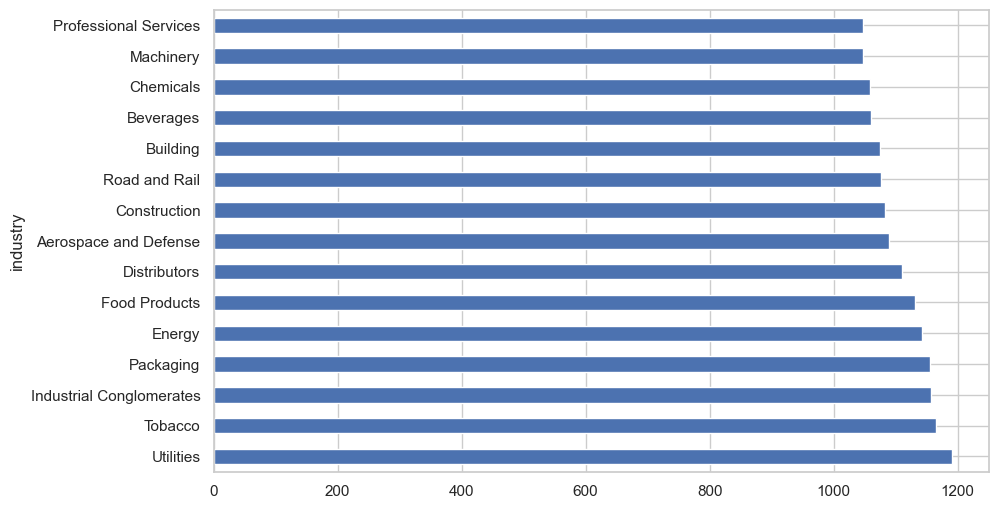

In [60]:
#Insights
# Setores mais sustentáveis
# Setores mais atrasados em ESG
industry_score.head(15).plot(kind='barh')


Verifica se os grupos Low, Medium e High estão bem separados.
Avalia a consistência da classificação adotada.
Permite validar a segmentação utilizada.

A clara separação entre os grupos indica que a categorização dos níveis ESG representa adequadamente as 
diferenças observadas nos scores totais.



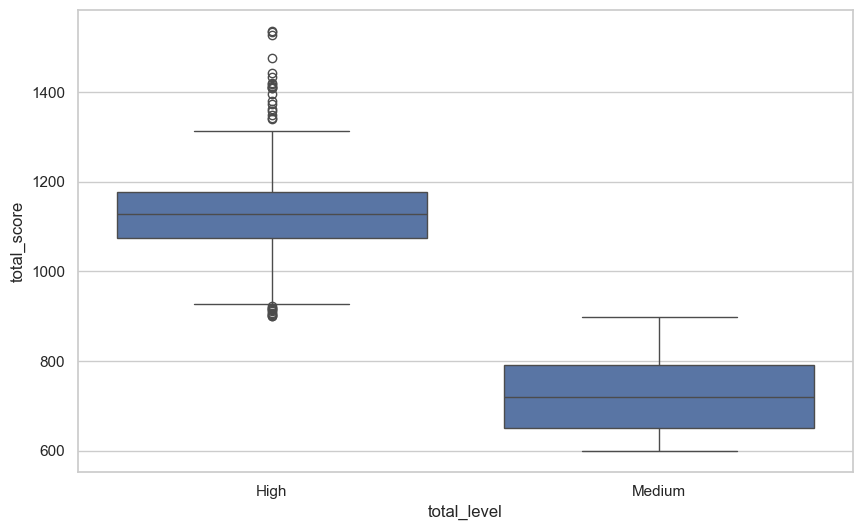

In [61]:
# 7. Comparação entre Níveis ESG
sns.boxplot(
    data=df,
    x='total_level',
    y='total_score'
)

#insights
print("""
Verifica se os grupos Low, Medium e High estão bem separados.
Avalia a consistência da classificação adotada.
Permite validar a segmentação utilizada.

A clara separação entre os grupos indica que a categorização dos níveis ESG representa adequadamente as 
diferenças observadas nos scores totais.
""")


Mostra o balanceamento entre as categorias.
Identifica qual classificação é predominante.
Permite avaliar possíveis desequilíbrios da base.

A distribuição dos níveis ESG evidencia a proporção de empresas em cada categoria, 
permitindo identificar o perfil predominante da amostra analisada.



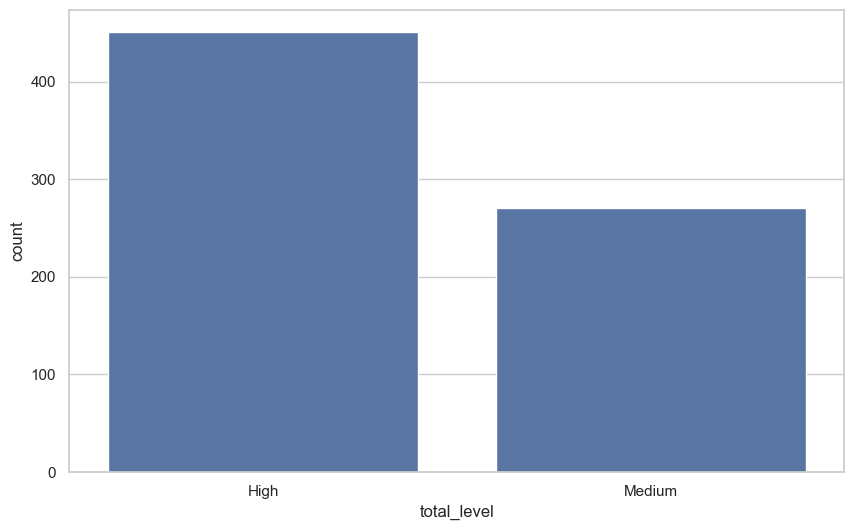

In [62]:
#Visualização 8 Distribuição dos níveis

sns.countplot(
    data=df,
    x='total_level'
)

#insights
print("""
Mostra o balanceamento entre as categorias.
Identifica qual classificação é predominante.
Permite avaliar possíveis desequilíbrios da base.
      
A distribuição dos níveis ESG evidencia a proporção de empresas em cada categoria, 
permitindo identificar o perfil predominante da amostra analisada.
""")


Identifica a nota ESG mais frequente.
Permite avaliar a concentração das empresas em determinados níveis de desempenho.
Auxilia na compreensão da maturidade ESG da base.

A distribuição das notas ESG demonstra como as empresas estão posicionadas nas diferentes 
classificações de desempenho, permitindo avaliar o grau geral de maturidade ESG da amostra.



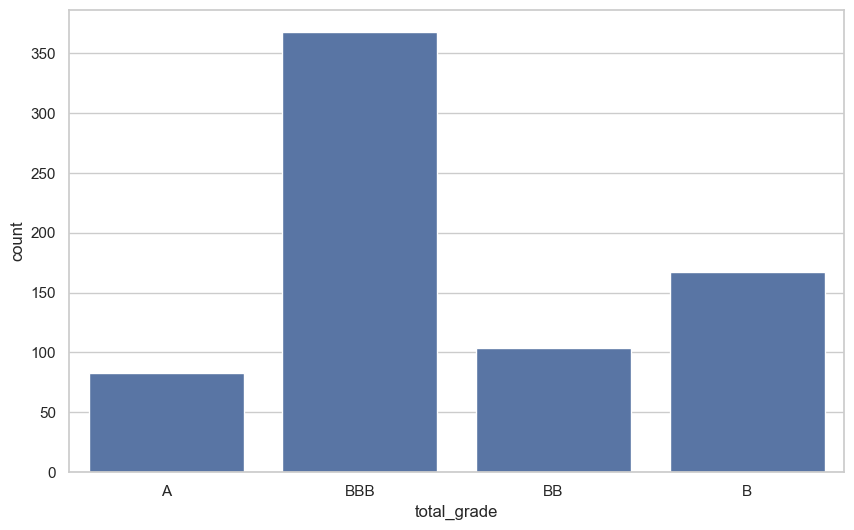

In [63]:
# Visualização 9 Análise das Notas (Grades)

# Frequência das notas
df['total_grade'].value_counts()
sns.countplot(
    data=df,
    x='total_grade',
    order=['A','BBB','BB','B']
)

#insights
print("""
Identifica a nota ESG mais frequente.
Permite avaliar a concentração das empresas em determinados níveis de desempenho.
Auxilia na compreensão da maturidade ESG da base.

A distribuição das notas ESG demonstra como as empresas estão posicionadas nas diferentes 
classificações de desempenho, permitindo avaliar o grau geral de maturidade ESG da amostra.
""")


Identifica as empresas líderes em desempenho ESG.
Permite estabelecer benchmarks.
Destaca organizações que podem servir como referência para melhores práticas.

As empresas presentes entre os maiores scores ESG representam referências de desempenho 
sustentável dentro da amostra analisada, podendo servir como benchmark para outras organizações.



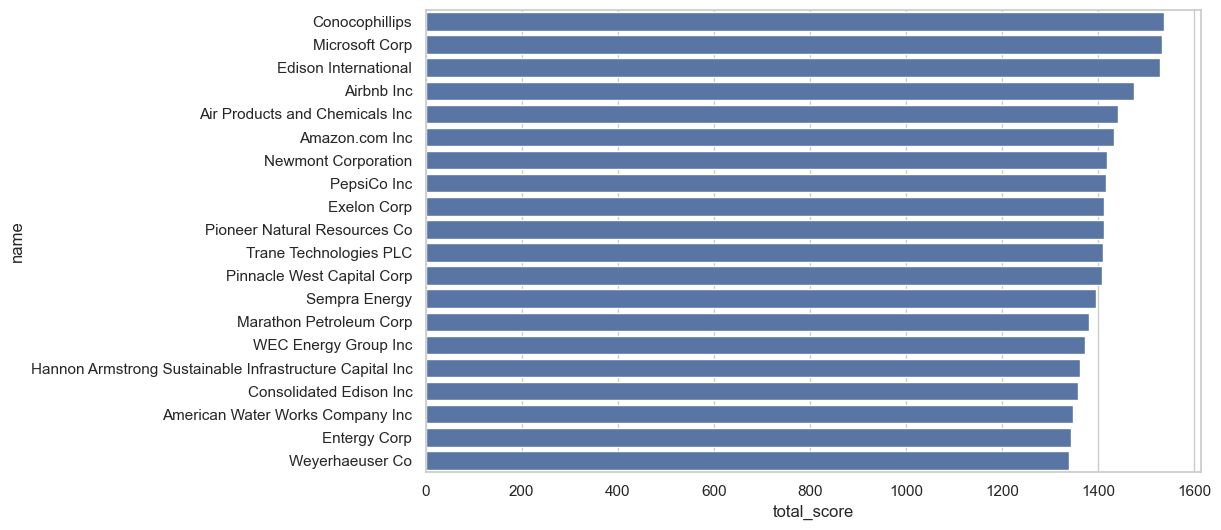

In [64]:
# 10: Ranking das Empresas
# Top 20 empresas ESG
df.nlargest(20,'total_score')
top20 = df.nlargest(20,'total_score')

sns.barplot(
    data=top20,
    x='total_score',
    y='name'
)

#insights
print("""
Identifica as empresas líderes em desempenho ESG.
Permite estabelecer benchmarks.
Destaca organizações que podem servir como referência para melhores práticas.
      
As empresas presentes entre os maiores scores ESG representam referências de desempenho 
sustentável dentro da amostra analisada, podendo servir como benchmark para outras organizações.
""")


Identifica as empresas com pior desempenho ESG.
Permite localizar possíveis focos de melhoria.
Ajuda a direcionar ações corretivas e programas de desenvolvimento.

As empresas com menores scores ESG representam os principais pontos de atenção da amostra analisada, 
indicando oportunidades para implementação de melhorias em práticas ambientais, sociais e de governança.



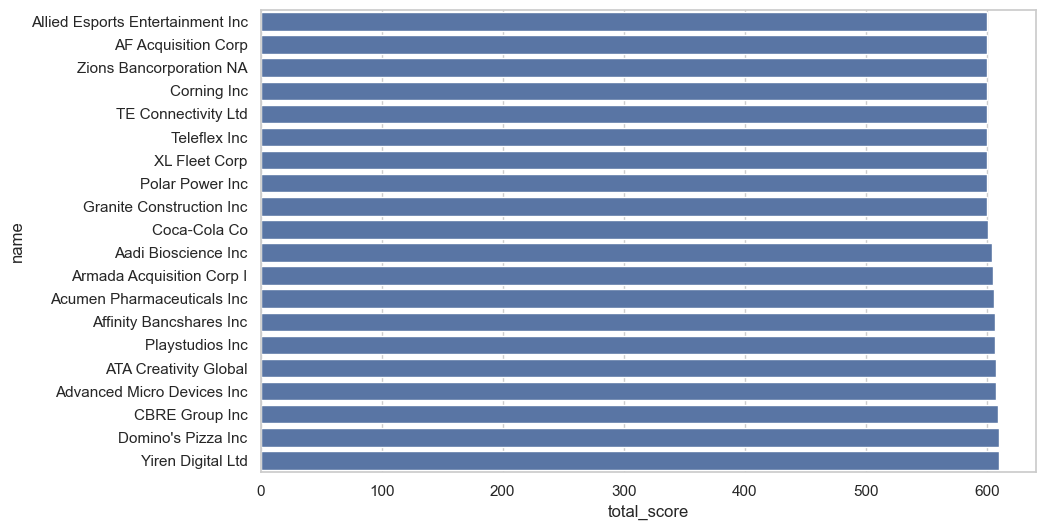

In [65]:
# 11: Bottom 20 empresas
bottom20 = df.nsmallest(20,'total_score')

sns.barplot(
    data=bottom20,
    x='total_score',
    y='name'
)
#insights
print("""
Identifica as empresas com pior desempenho ESG.
Permite localizar possíveis focos de melhoria.
Ajuda a direcionar ações corretivas e programas de desenvolvimento.
      
As empresas com menores scores ESG representam os principais pontos de atenção da amostra analisada, 
indicando oportunidades para implementação de melhorias em práticas ambientais, sociais e de governança.
""")


Permite visualizar relações entre todos os pilares ESG simultaneamente.
Facilita a identificação de correlações.
Pode revelar agrupamentos naturais.
Mostra a distribuição individual de cada variável.

O pairplot oferece uma visão integrada das relações entre os indicadores ESG, permitindo 
identificar padrões de associação, dispersão e possíveis agrupamentos de empresas com características 
semelhantes.



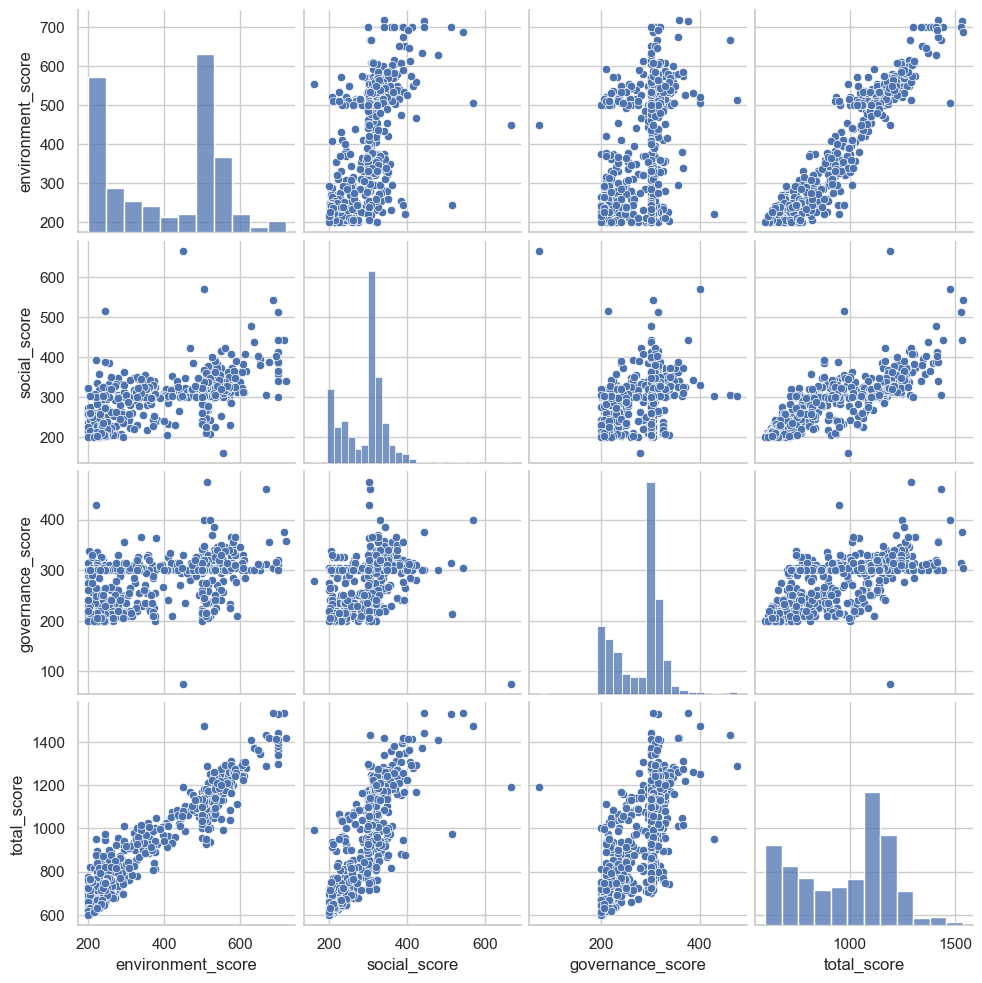

In [66]:
# 12 Análise Multivariada Pairplot
sns.pairplot(
    df[
        [
            'environment_score',
            'social_score',
            'governance_score',
            'total_score'
        ]
    ]
)

#insights
print("""
Permite visualizar relações entre todos os pilares ESG simultaneamente.
Facilita a identificação de correlações.
Pode revelar agrupamentos naturais.
Mostra a distribuição individual de cada variável.
      
O pairplot oferece uma visão integrada das relações entre os indicadores ESG, permitindo 
identificar padrões de associação, dispersão e possíveis agrupamentos de empresas com características 
semelhantes.
""")